In [22]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [23]:
df = pd.read_csv("CustomerData.csv")
df


,CustomerID,Age,Gender,City,AnnualIncome,TotalSpent,MonthlyPurchases,AvgOrderValue,AppTimeMinutes,DiscountUsage,PreferredShoppingTime
0,C001,28,F,Bangalore,450000.0,120000,6,2000,45.0,Medium,Night
1,C002,35,M,Mumbai,1200000.0,850000,18,12000,120.0,Low,Night
2,C003,42,F,Delhi,300000.0,75000,3,1800,30.0,High,Day
3,C004,26,M,Pune,NaN,40000,2,1500,20.0,High,Day
4,C005,39,F,Bangalore,950000.0,600000,15,9000,95.0,Low,Night
...,...,...,...,...,...,...,...,...,...,...,...
95,C096,32,M,Kolkata,520000.0,210000,8,2800,64.0,Medium,Day
96,C097,55,M,Bangalore,1400000.0,980000,20,14500,150.0,Low,Night
97,C098,37,F,Pune,590000.0,260000,9,3100,69.0,Medium,Day
98,C099,24,M,Delhi,200000.0,30000,1,1200,10.0,High,Day


In [24]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = [
    "Gender",
    "City",
    "DiscountUsage",
    "PreferredShoppingTime"
]

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [30]:
df = df.dropna()


In [31]:
features = [
    "Age",
    "Gender",
    "City",
    "AnnualIncome",
    "TotalSpent",
    "MonthlyPurchases",
    "AvgOrderValue",
    "AppTimeMinutes",
    "DiscountUsage",
    "PreferredShoppingTime"
]

X = df[features]


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)


In [ ]:
cluster_summary = df.groupby("Cluster").agg({
    "Age": "mean",
    "AnnualIncome": "mean",
    "TotalSpent": "mean",
    "MonthlyPurchases": "mean",
    "AvgOrderValue": "mean",
    "AppTimeMinutes": "mean",
    "Gender": lambda x: x.mode()[0],                
    "City": lambda x: x.mode()[0],
    "DiscountUsage": lambda x: x.mode()[0],
    "PreferredShoppingTime": lambda x: x.mode()[0]
})

print(cluster_summary)


               Age  AnnualIncome    TotalSpent  MonthlyPurchases  \
Cluster                                                            
0        38.511111  6.711111e+05  3.334444e+05         10.444444   
1        49.666667  1.457222e+06  1.037778e+06         19.555556   
2        32.405405  3.875676e+05  1.220270e+05          4.513514   

         AvgOrderValue  AppTimeMinutes  Gender  City  DiscountUsage  \
Cluster                                                               
0          4572.222222       78.244444       0     0              2   
1         13900.000000      148.611111       1     5              1   
2          2124.324324       37.432432       0     6              0   

         PreferredShoppingTime  
Cluster                         
0                            1  
1                            1  
2                            0  


In [36]:
cluster_labels = {
    0: "High-Value Loyal Customers",
    1: "Value-Seeking Regular Customers",
    2: "Price-Sensitive Occasional Customers"
}

df["Customer Segment"] = df["Cluster"].map(cluster_labels)


In [37]:
offers = {
    "High-Value Loyal Customers": 
        "Exclusive early access to new products + Premium membership with free express delivery",

    "Value-Seeking Regular Customers": 
        "Festival discounts (10–15%) + Loyalty reward points",

    "Price-Sensitive Occasional Customers": 
        "Flash sales, coupons, and free shipping on minimum order"
}

df["Recommended Offer"] = df["Customer Segment"].map(offers)


In [38]:
df_final = df[
    ["Customer Segment", "Recommended Offer"]
]

print(df_final.head())


                       Customer Segment  \
0            High-Value Loyal Customers   
1       Value-Seeking Regular Customers   
2  Price-Sensitive Occasional Customers   
3  Price-Sensitive Occasional Customers   
4            High-Value Loyal Customers   

                                   Recommended Offer  
0  Exclusive early access to new products + Premi...  
1  Festival discounts (10–15%) + Loyalty reward p...  
2  Flash sales, coupons, and free shipping on min...  
3  Flash sales, coupons, and free shipping on min...  
4  Exclusive early access to new products + Premi...  


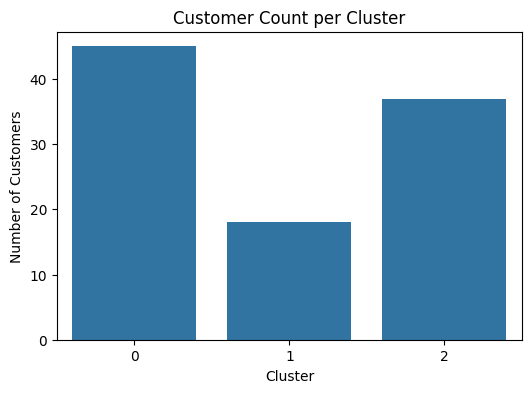

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Cluster", data=df)
plt.title("Customer Count per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()


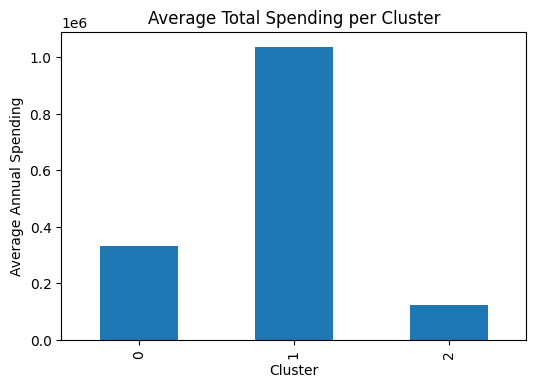

In [ ]:
avg_spending = df.groupby("Cluster")["TotalSpent"].median()

plt.figure(figsize=(6,4))
avg_spending.plot(kind="bar")
plt.title("Average Total Spending per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Annual Spending")
plt.show()


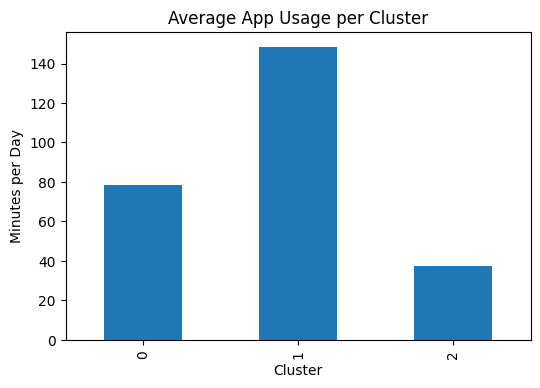

In [43]:
avg_app_usage = df.groupby("Cluster")[
    "AppTimeMinutes"
].mean()

plt.figure(figsize=(6,4))
avg_app_usage.plot(kind="bar")
plt.title("Average App Usage per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Minutes per Day")
plt.show()


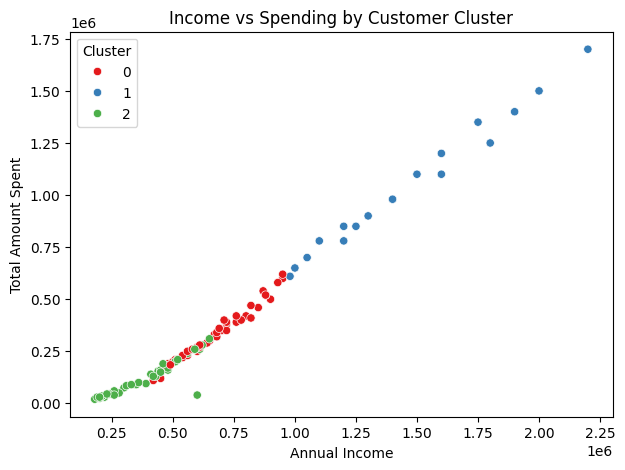

In [45]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x="AnnualIncome",
    y="TotalSpent",
    hue="Cluster",
    data=df,
    palette="Set1"
)

plt.title("Income vs Spending by Customer Cluster")
plt.xlabel("Annual Income")
plt.ylabel("Total Amount Spent")
plt.show()


In [46]:
import pickle

with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)


In [47]:
df["Offer Given"] = df["Cluster"].map(offers)
df["Customer Segment"] = df["Cluster"].map(cluster_labels)

df.to_csv("customer_data_with_offers.csv", index=False)
